# Red Neuronal para Regresión — Dataset de Salarios Tech
**Variable dependiente:** `salario` (salario anual en USD)

In [1]:
# =============================================================================
# RED NEURONAL PARA REGRESIÓN - Dataset de Salarios Tech
# Variable dependiente: salario (salario anual en USD)
# =============================================================================
! pip install tensorflow scikit-learn openpyxl --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 55)
print("   RED NEURONAL - PREDICCIÓN DE SALARIOS TECH")
print("   Variable objetivo: salario (USD anuales)")
print("=" * 55)


   RED NEURONAL - PREDICCIÓN DE SALARIOS TECH
   Variable objetivo: salario (USD anuales)


In [2]:
# ================================
# 1. CARGA Y EXPLORACIÓN DE DATOS
# ================================
df = pd.read_excel("datossalarios.xlsx")

print(f"\n    Shape: {df.shape}  →  {df.shape[0]:,} profesionales, {df.shape[1]} variables")
print(f"\n    Columnas: {list(df.columns)}")
print(f"\n    Primeras filas:")
print(df.head())



    Shape: (250000, 10)  →  250,000 profesionales, 10 variables

    Columnas: ['titulo_profesional', 'anios_experiencia', 'nivel_educativo', 'numero_habilidades', 'industria', 'tamaño_empresa', 'ubicación', 'trabajo_remoto', 'certificaciones', 'salario']

    Primeras filas:
   titulo_profesional  anios_experiencia nivel_educativo  numero_habilidades  \
0         AI Engineer                 10        Bachelor                   2   
1        Data Analyst                  5        Bachelor                  17   
2  Frontend Developer                 18             PhD                   4   
3    Business Analyst                 19             PhD                  13   
4     Product Manager                 15        Bachelor                   7   

       industria tamaño_empresa  ubicación trabajo_remoto  certificaciones  \
0     Healthcare         Medium      India         Hybrid                2   
1        Telecom          Small  Australia             No                0   
2      

In [3]:
# Análisis Exploratorio (EDA)
print("\n    Estadísticas descriptivas:")
print(df.describe(include="all").T.to_string())

print(f"\n    Valores nulos por columna:")
print(df.isnull().sum())

# Descripción de variables
descripcion = {
    "titulo_profesional" : "Rol o cargo tecnológico (10 categorías)",
    "anios_experiencia"  : "Años de experiencia laboral (0-20)",
    "nivel_educativo"    : "Nivel educativo (High School / Diploma / Bachelor / Master / PhD)",
    "numero_habilidades" : "Número de habilidades técnicas registradas",
    "industria"          : "Sector industrial (10 categorías)",
    "tamaño_empresa"     : "Tamaño de empresa (Startup / Small / Medium / Large / Enterprise)",
    "ubicación"          : "País de trabajo (10 países + Remote)",
    "trabajo_remoto"     : "Modalidad de trabajo (No / Hybrid / Yes)",
    "certificaciones"    : "Número de certificaciones profesionales (0-5)",
    "salario"            : "*** VARIABLE OBJETIVO: Salario anual en USD ***"
}
print("\n    Descripción de variables:")
for col, desc in descripcion.items():
    print(f"    {col:>20} → {desc}")



    Estadísticas descriptivas:
                       count unique                top   freq           mean           std      min       25%       50%       75%       max
titulo_profesional    250000     12  Backend Developer  21125            NaN           NaN      NaN       NaN       NaN       NaN       NaN
anios_experiencia   250000.0    NaN                NaN    NaN      10.005408      6.060602      0.0       5.0      10.0      15.0      20.0
nivel_educativo       250000      5             Master  50352            NaN           NaN      NaN       NaN       NaN       NaN       NaN
numero_habilidades  250000.0    NaN                NaN    NaN       9.997812      5.479288      1.0       5.0      10.0      15.0      19.0
industria             250000     10            Finance  25393            NaN           NaN      NaN       NaN       NaN       NaN       NaN
tamaño_empresa        250000      5              Large  50254            NaN           NaN      NaN       NaN       NaN       Na

Variables numéricas: ['anios_experiencia', 'numero_habilidades', 'certificaciones', 'salario']


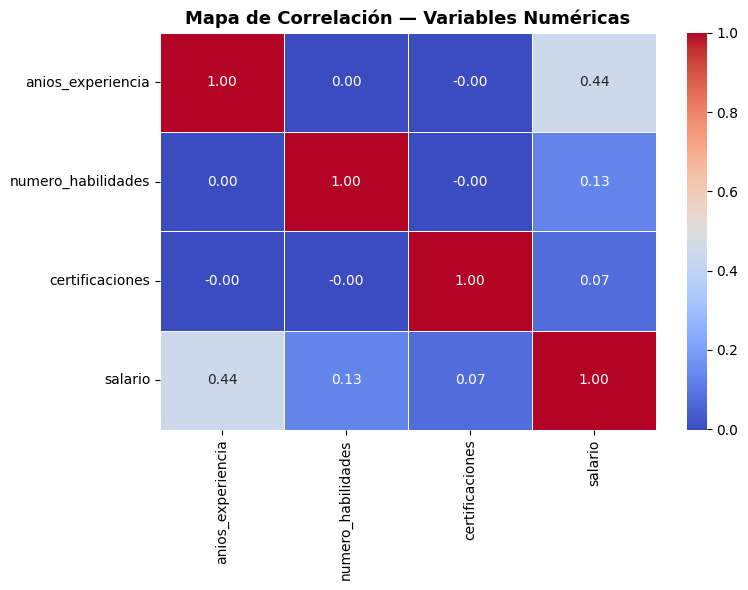

    Gráfico guardado: correlacion_salarios.png


In [4]:
# Mapa de calor de correlación (variables numéricas)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Variables numéricas:", num_cols)

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de Correlación — Variables Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlacion_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Gráfico guardado: correlacion_salarios.png")


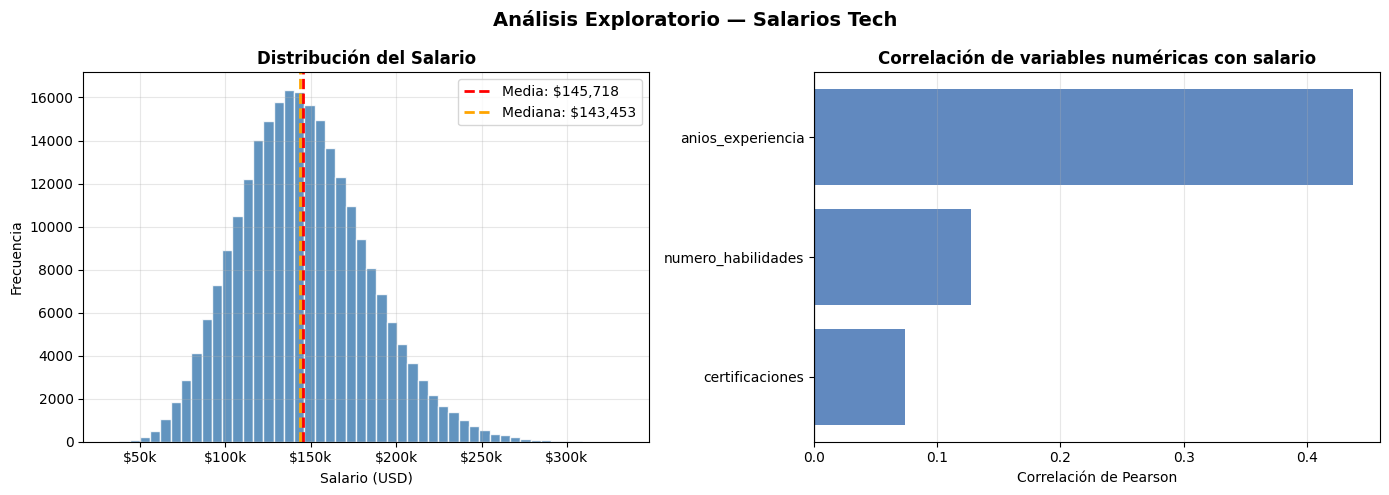

    Gráfico guardado: exploratorio_salarios.png


In [5]:
# ================================
# 2. ANÁLISIS EXPLORATORIO RÁPIDO
# ================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis Exploratorio — Salarios Tech", fontsize=14, fontweight="bold")

# Distribución del salario
axes[0].hist(df["salario"], bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["salario"].mean(),   color="red",    linestyle="--", linewidth=2,
                label=f"Media: ${df['salario'].mean():,.0f}")
axes[0].axvline(df["salario"].median(), color="orange", linestyle="--", linewidth=2,
                label=f"Mediana: ${df['salario'].median():,.0f}")
axes[0].set_title("Distribución del Salario", fontweight="bold")
axes[0].set_xlabel("Salario (USD)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# Correlación de numéricas con salario
corr_sal = df[num_cols].corr()["salario"].drop("salario").sort_values()
colores  = ["#d73027" if c < 0 else "#4575b4" for c in corr_sal]
axes[1].barh(corr_sal.index, corr_sal.values, color=colores, alpha=0.85)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de variables numéricas con salario", fontweight="bold")
axes[1].set_xlabel("Correlación de Pearson")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("exploratorio_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Gráfico guardado: exploratorio_salarios.png")


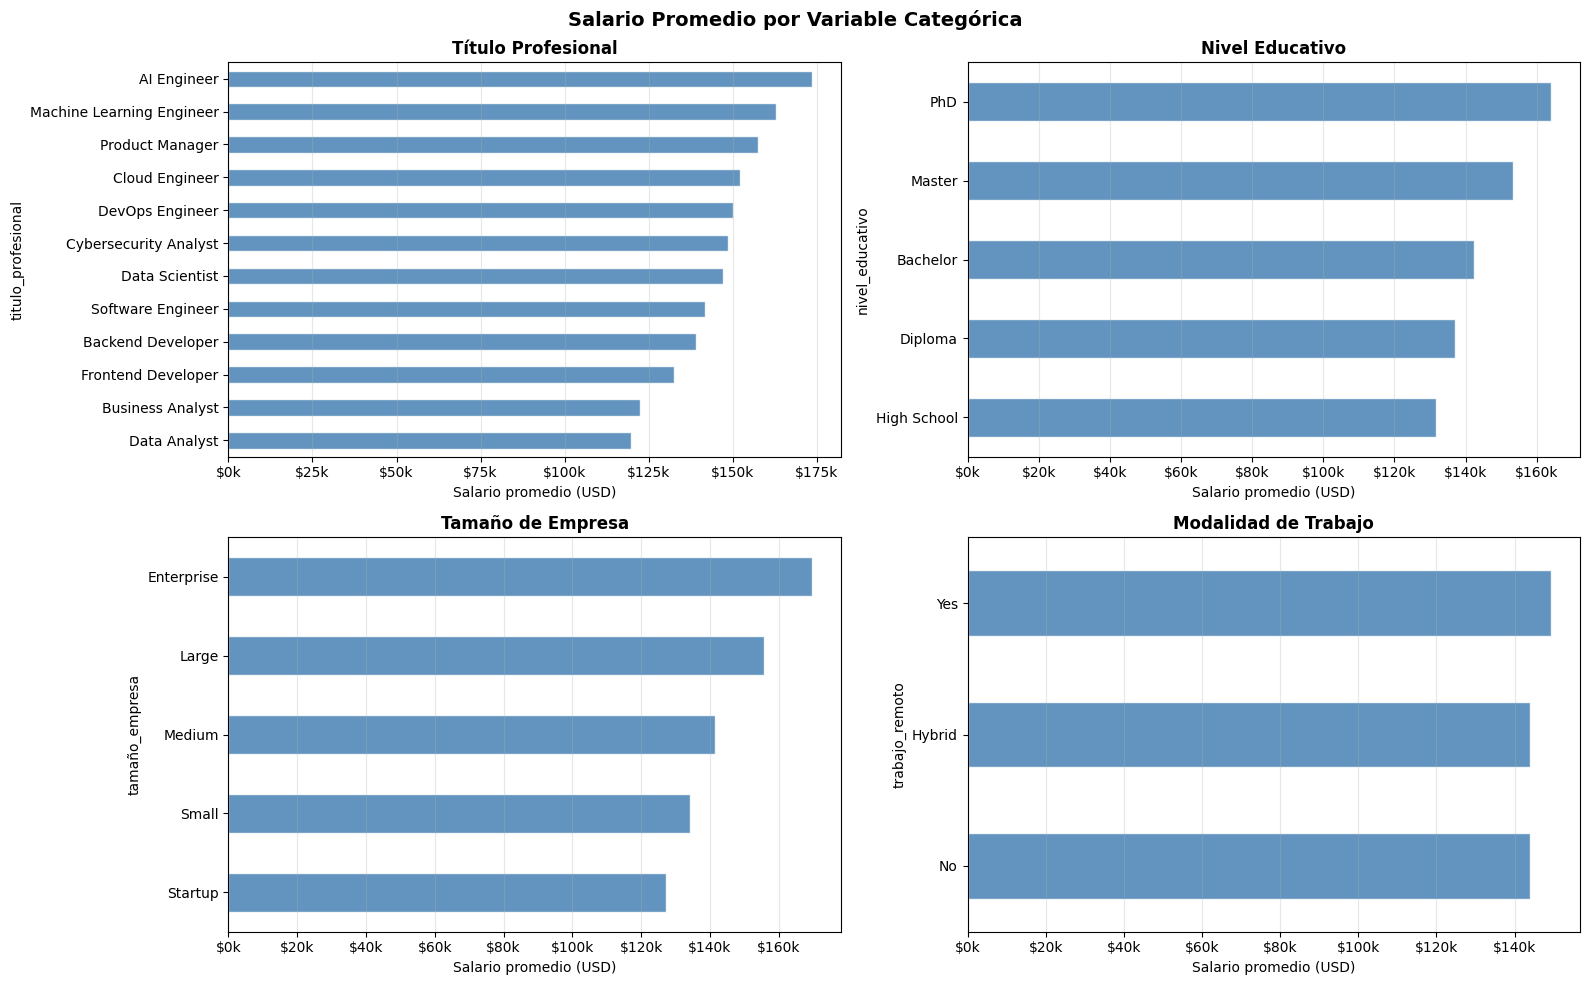

    Gráfico guardado: categoricas_salarios.png


In [6]:
# Salario promedio por variable categórica
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Salario Promedio por Variable Categórica", fontsize=14, fontweight="bold")

cat_plots = [
    ("titulo_profesional", axes[0, 0], "Título Profesional"),
    ("nivel_educativo",    axes[0, 1], "Nivel Educativo"),
    ("tamaño_empresa",     axes[1, 0], "Tamaño de Empresa"),
    ("trabajo_remoto",     axes[1, 1], "Modalidad de Trabajo"),
]

orden_nivel  = ["High School", "Diploma", "Bachelor", "Master", "PhD"]
orden_tamano = ["Startup", "Small", "Medium", "Large", "Enterprise"]
orden_remote = ["No", "Hybrid", "Yes"]

ordenes = {
    "nivel_educativo": orden_nivel,
    "tamaño_empresa" : orden_tamano,
    "trabajo_remoto" : orden_remote,
}

for col, ax, titulo in cat_plots:
    orden = ordenes.get(col, None)
    med   = df.groupby(col)["salario"].mean().sort_values()
    if orden:
        med = med.reindex([o for o in orden if o in med.index])
    med.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Salario promedio (USD)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("categoricas_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Gráfico guardado: categoricas_salarios.png")


In [7]:
# ========================
# 3. PREPARACIÓN DE DATOS
# ========================

# --- Codificación de variables categóricas ---

# Ordinales con orden natural
edu_map    = {"High School": 0, "Diploma": 1, "Bachelor": 2, "Master": 3, "PhD": 4}
tamano_map = {"Startup": 0, "Small": 1, "Medium": 2, "Large": 3, "Enterprise": 4}
remote_map = {"No": 0, "Hybrid": 1, "Yes": 2}

df["edu_enc"]    = df["nivel_educativo"].map(edu_map)
df["tamano_enc"] = df["tamaño_empresa"].map(tamano_map)
df["remote_enc"] = df["trabajo_remoto"].map(remote_map)

# Nominales → one-hot (drop_first=True para evitar multicolinealidad)
titulo_dummies   = pd.get_dummies(df["titulo_profesional"], prefix="titulo",   drop_first=True)
industria_dummies = pd.get_dummies(df["industria"],         prefix="ind",      drop_first=True)
ubicacion_dummies = pd.get_dummies(df["ubicación"],         prefix="ubi",      drop_first=True)

df_model = pd.concat([df, titulo_dummies, industria_dummies, ubicacion_dummies], axis=1)

# --- Construir lista de features ---
feature_cols = (
    ["anios_experiencia", "edu_enc", "numero_habilidades",
     "tamano_enc", "remote_enc", "certificaciones"]
    + list(titulo_dummies.columns)
    + list(industria_dummies.columns)
    + list(ubicacion_dummies.columns)
)

TARGET = "salario"
X = df_model[feature_cols]
y = df_model[TARGET]

print(f"    Variables predictoras ({X.shape[1]}): {list(X.columns)}")
print(f"\n    Variable objetivo: {TARGET}")
print(f"    Rango de salario: [${y.min():,}, ${y.max():,}]")
print(f"    Media: ${y.mean():,.0f} | Std: ${y.std():,.0f}")


    Variables predictoras (35): ['anios_experiencia', 'edu_enc', 'numero_habilidades', 'tamano_enc', 'remote_enc', 'certificaciones', 'titulo_Backend Developer', 'titulo_Business Analyst', 'titulo_Cloud Engineer', 'titulo_Cybersecurity Analyst', 'titulo_Data Analyst', 'titulo_Data Scientist', 'titulo_DevOps Engineer', 'titulo_Frontend Developer', 'titulo_Machine Learning Engineer', 'titulo_Product Manager', 'titulo_Software Engineer', 'ind_Education', 'ind_Finance', 'ind_Government', 'ind_Healthcare', 'ind_Manufacturing', 'ind_Media', 'ind_Retail', 'ind_Technology', 'ind_Telecom', 'ubi_Canada', 'ubi_Germany', 'ubi_India', 'ubi_Netherlands', 'ubi_Remote', 'ubi_Singapore', 'ubi_Sweden', 'ubi_UK', 'ubi_USA']

    Variable objetivo: salario
    Rango de salario: [$31,867, $333,046]
    Media: $145,718 | Std: $37,408


In [8]:
# División en Entrenamiento / Validación / Prueba
# Split: 70% train | 15% val | 15% test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42
)

print(f"\n    División del dataset:")
print(f"    ├── Train:      {X_train.shape[0]:>7,} muestras ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"    ├── Validación: {X_val.shape[0]:>7,} muestras ({X_val.shape[0]/len(df)*100:.0f}%)")
print(f"    └── Test:       {X_test.shape[0]:>7,} muestras ({X_test.shape[0]/len(df)*100:.0f}%)")



    División del dataset:
    ├── Train:      175,100 muestras (70%)
    ├── Validación:  37,400 muestras (15%)
    └── Test:        37,500 muestras (15%)


In [9]:
# ====================================================
# 4. ESCALADO (fit SOLO en train → evita data leakage)
# ====================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.values.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print("    ✓ Escalado completado sin data leakage.")


    ✓ Escalado completado sin data leakage.


In [10]:
# ===================================
# 5. ARQUITECTURA DE LA RED NEURONAL
# ===================================

def build_model(input_dim, learning_rate=0.001):
    """
    Arquitectura para dataset de salarios (250,000 muestras):
    - Dataset grande → capas más amplias, regularización moderada
    - BatchNorm + Dropout para evitar overfitting
    - Salida lineal (regresión de salario)
    """
    model = keras.Sequential([

        # Capa oculta 1: 256 neuronas
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
            input_shape=(input_dim,),
            name="oculta_1"
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Capa oculta 2: 128 neuronas
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
            name="oculta_2"
        ),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        # Capa oculta 3: 64 neuronas
        layers.Dense(
            64,
            activation="relu",
            name="oculta_3"
        ),
        layers.Dropout(0.1),

        # Capa oculta 4: 32 neuronas
        layers.Dense(
            32,
            activation="relu",
            name="oculta_4"
        ),

        # Salida: 1 neurona, activación LINEAL → regresión
        layers.Dense(1, activation="linear", name="salida")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

input_dim = X_train_sc.shape[1]
model = build_model(input_dim)

print("\n    Resumen de la arquitectura:")
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



    Resumen de la arquitectura:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_4 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,017 (211.00 KB)

 Trainable params: 53,249 (208.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [11]:
# ==============
# 6. CALLBACKS
# ==============

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    filepath="mejor_modelo_salarios.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=0
)

print("    ✓ EarlyStopping | ReduceLROnPlateau | ModelCheckpoint")
lista_callbacks = [early_stop, reduce_lr, checkpoint]


    ✓ EarlyStopping | ReduceLROnPlateau | ModelCheckpoint


In [12]:
# =================
# 7. ENTRENAMIENTO
# =================
print("\n[7] Entrenando red neuronal...")
print("    Dataset grande (250k muestras) → batch_size=128 para mayor velocidad")
print("    (Se detendrá si val_loss no mejora en 20 épocas)\n")

history = model.fit(
    X_train_sc, y_train_sc,
    validation_data=(X_val_sc, y_val_sc),
    epochs=200,
    batch_size=128,
    callbacks=lista_callbacks,
    verbose=1
)

epocas_reales = len(history.history["loss"])
print(f"\n    ✓ Entrenamiento finalizado en {epocas_reales} épocas.")



[7] Entrenando red neuronal...
    Dataset grande (250k muestras) → batch_size=128 para mayor velocidad
    (Se detendrá si val_loss no mejora en 20 épocas)

Epoch 1/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.2807 - mae: 0.2580 - val_loss: 0.1171 - val_mae: 0.1608 - learning_rate: 0.0010
Epoch 2/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 0.0900 - mae: 0.1795 - val_loss: 0.0576 - val_mae: 0.1632 - learning_rate: 0.0010
Epoch 3/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0575 - mae: 0.1684 - val_loss: 0.0459 - val_mae: 0.1531 - learning_rate: 0.0010
Epoch 4/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0531 - mae: 0.1649 - val_loss: 0.0497 - val_mae: 0.1581 - learning_rate: 0.0010
Epoch 5/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.0511 - mae: 0.1620 - val_loss: 0.0481 - val_mae: 0.1582 - learning_rate: 0.0010
Epoch 6/200
1368/1368 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0499 - mae: 0.1604 - val_loss: 0.0472 - val_ma

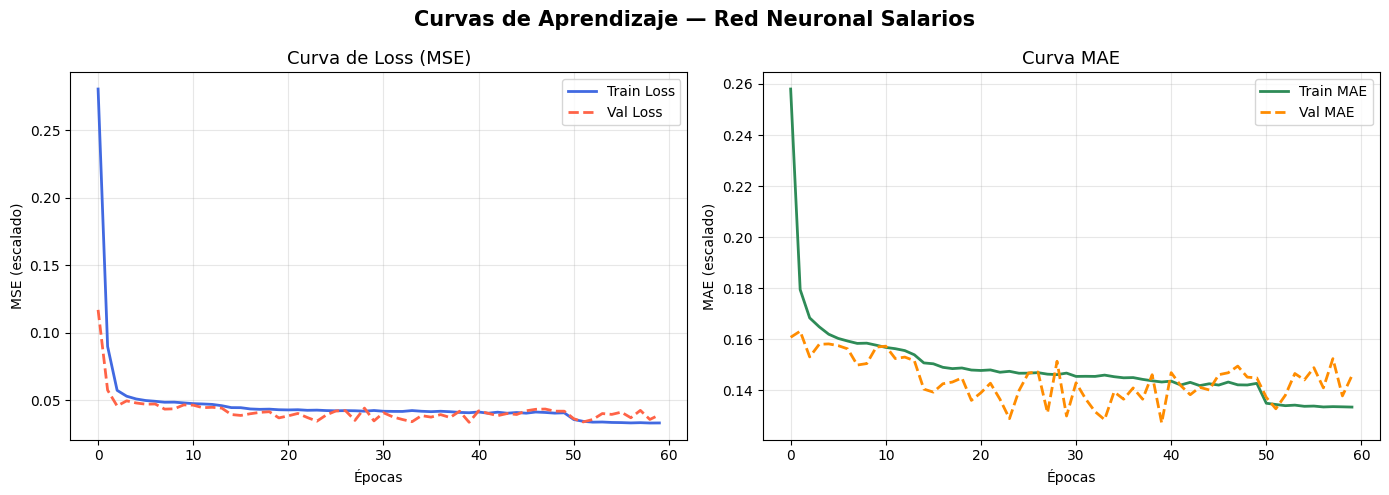

In [13]:
# Curvas de aprendizaje
hist_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["loss"],     label="Train Loss", color="royalblue",  linewidth=2)
axes[0].plot(hist_df["val_loss"], label="Val Loss",   color="tomato",     linewidth=2, linestyle="--")
axes[0].set_title("Curva de Loss (MSE)", fontsize=13)
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("MSE (escalado)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["mae"],     label="Train MAE", color="seagreen",   linewidth=2)
axes[1].plot(hist_df["val_mae"], label="Val MAE",   color="darkorange", linewidth=2, linestyle="--")
axes[1].set_title("Curva MAE", fontsize=13)
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("MAE (escalado)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizaje — Red Neuronal Salarios", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


In [14]:
# ======================
# 8. EVALUACIÓN EN TEST
# ======================

# Predicciones → desescalar a USD reales
y_pred_sc = model.predict(X_test_sc, verbose=0)
y_pred    = scaler_y.inverse_transform(y_pred_sc).ravel()
y_real    = y_test.values

# Métricas
mse  = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_real, y_pred)
r2   = r2_score(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print("\n" + "=" * 55)
print("   MÉTRICAS EN CONJUNTO TEST")
print("=" * 55)
print(f"   MSE   : {mse:,.2f}")
print(f"   RMSE  : ${rmse:,.2f}  USD")
print(f"   MAE   : ${mae:,.2f}  USD")
print(f"   MAPE  : {mape:.2f}%")
print(f"   R²    : {r2:.4f}  ({r2*100:.1f}% varianza explicada)")
print("=" * 55)
print(f"\n   Interpretación:")
print(f"   → El modelo se equivoca en promedio ±${mae:,.0f} USD por año")
print(f"   → Explica el {r2*100:.1f}% de la variabilidad salarial")



   MÉTRICAS EN CONJUNTO TEST
   MSE   : 35,958,200.00
   RMSE  : $5,996.52  USD
   MAE   : $4,780.94  USD
   MAPE  : 3.61%
   R²    : 0.9741  (97.4% varianza explicada)

   Interpretación:
   → El modelo se equivoca en promedio ±$4,781 USD por año
   → Explica el 97.4% de la variabilidad salarial


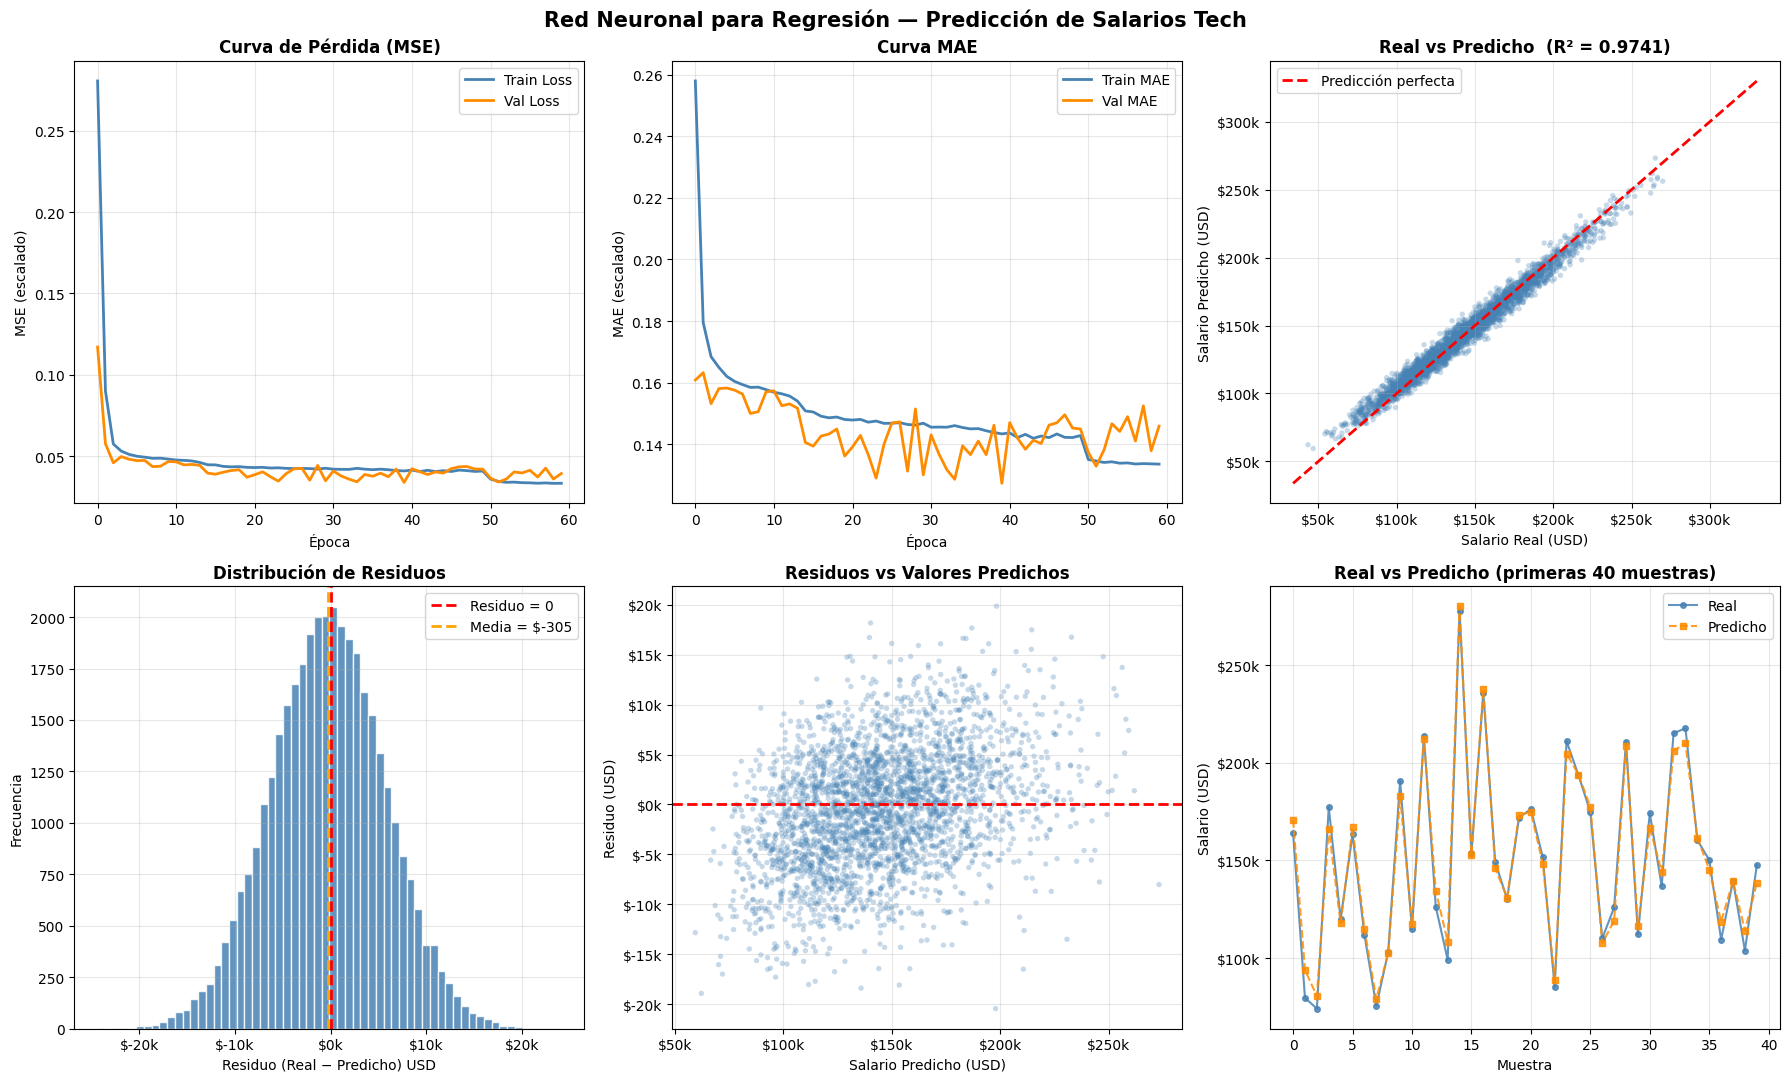

    ✓ Gráficos guardados: resultados_salarios.png


In [15]:
# =============================
# 9. VISUALIZACIONES COMPLETAS
# =============================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Red Neuronal para Regresión — Predicción de Salarios Tech",
             fontsize=15, fontweight="bold")

fmt_usd = plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k")

# --- Plot 1: Curva de pérdida MSE ---
ax = axes[0, 0]
ax.plot(history.history["loss"],     label="Train Loss", color="steelblue",  linewidth=2)
ax.plot(history.history["val_loss"], label="Val Loss",   color="darkorange", linewidth=2)
ax.set_title("Curva de Pérdida (MSE)", fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("MSE (escalado)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Curva MAE ---
ax = axes[0, 1]
ax.plot(history.history["mae"],     label="Train MAE", color="steelblue",  linewidth=2)
ax.plot(history.history["val_mae"], label="Val MAE",   color="darkorange", linewidth=2)
ax.set_title("Curva MAE", fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("MAE (escalado)")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: Real vs Predicho ---
ax = axes[0, 2]
# Muestra aleatoria para no sobrecargar el scatter
idx = np.random.choice(len(y_real), min(3000, len(y_real)), replace=False)
ax.scatter(y_real[idx], y_pred[idx], alpha=0.3, color="steelblue", s=15,
           edgecolors="none")
lim_min = min(y_real.min(), y_pred.min()) - 5000
lim_max = max(y_real.max(), y_pred.max()) + 5000
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", linewidth=2, label="Predicción perfecta")
ax.set_title(f"Real vs Predicho  (R² = {r2:.4f})", fontweight="bold")
ax.set_xlabel("Salario Real (USD)")
ax.set_ylabel("Salario Predicho (USD)")
ax.xaxis.set_major_formatter(fmt_usd)
ax.yaxis.set_major_formatter(fmt_usd)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 4: Distribución de residuos ---
ax = axes[1, 0]
residuos = y_real - y_pred
ax.hist(residuos, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0,               color="red",    linestyle="--", linewidth=2, label="Residuo = 0")
ax.axvline(residuos.mean(), color="orange", linestyle="--", linewidth=2,
           label=f"Media = ${residuos.mean():,.0f}")
ax.set_title("Distribución de Residuos", fontweight="bold")
ax.set_xlabel("Residuo (Real − Predicho) USD")
ax.set_ylabel("Frecuencia")
ax.xaxis.set_major_formatter(fmt_usd)
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 5: Residuos vs Predichos ---
ax = axes[1, 1]
ax.scatter(y_pred[idx], residuos[idx], alpha=0.3, color="steelblue", s=15, edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=2)
ax.set_title("Residuos vs Valores Predichos", fontweight="bold")
ax.set_xlabel("Salario Predicho (USD)")
ax.set_ylabel("Residuo (USD)")
ax.xaxis.set_major_formatter(fmt_usd)
ax.yaxis.set_major_formatter(fmt_usd)
ax.grid(True, alpha=0.3)

# --- Plot 6: Real vs Predicho (primeras 40 muestras) ---
ax = axes[1, 2]
n_show = 40
indices = np.arange(n_show)
ax.plot(indices, y_real[:n_show],  "o-",  color="steelblue",  linewidth=1.5,
        markersize=4, label="Real", alpha=0.85)
ax.plot(indices, y_pred[:n_show],  "s--", color="darkorange", linewidth=1.5,
        markersize=4, label="Predicho", alpha=0.85)
ax.set_title(f"Real vs Predicho (primeras {n_show} muestras)", fontweight="bold")
ax.set_xlabel("Muestra")
ax.set_ylabel("Salario (USD)")
ax.yaxis.set_major_formatter(fmt_usd)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráficos guardados: resultados_salarios.png")



[10] Estimando importancia de variables (pesos capa 1)...


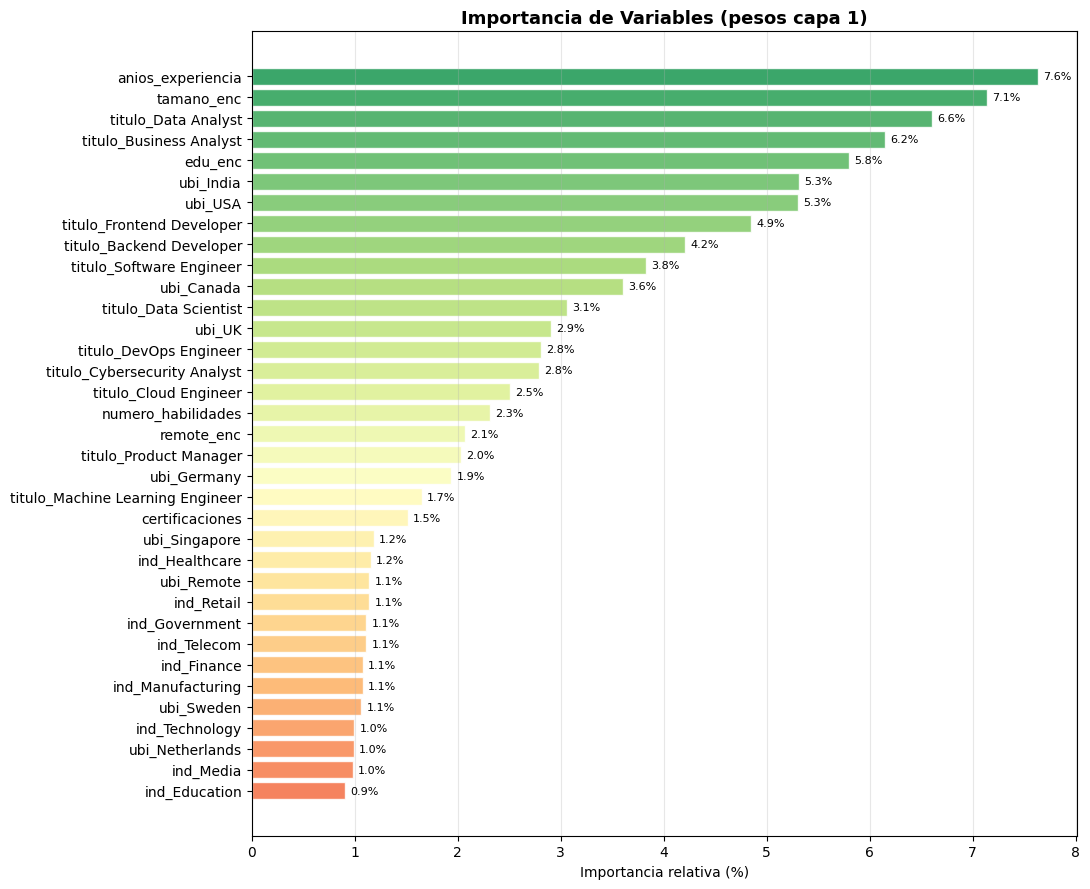

    ✓ Gráfico guardado: importancia_variables_salarios.png

    Top 8 variables más influyentes:
                 anios_experiencia → 7.6%
                        tamano_enc → 7.1%
               titulo_Data Analyst → 6.6%
           titulo_Business Analyst → 6.2%
                           edu_enc → 5.8%
                         ubi_India → 5.3%
                           ubi_USA → 5.3%
         titulo_Frontend Developer → 4.9%


In [16]:
# =============================================================================
# 10. IMPORTANCIA DE VARIABLES (por pesos de la primera capa)
# =============================================================================
print("\n[10] Estimando importancia de variables (pesos capa 1)...")

pesos_capa1      = np.abs(model.get_layer("oculta_1").get_weights()[0])
importancia      = pesos_capa1.mean(axis=1)
importancia_norm = importancia / importancia.sum() * 100

df_importancia = pd.DataFrame({
    "Variable"   : list(X.columns),
    "Importancia": importancia_norm
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))
colores_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(df_importancia)))
bars = ax.barh(df_importancia["Variable"], df_importancia["Importancia"],
               color=colores_imp, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, df_importancia["Importancia"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=8)

ax.set_title("Importancia de Variables (pesos capa 1)", fontweight="bold", fontsize=13)
ax.set_xlabel("Importancia relativa (%)")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("importancia_variables_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráfico guardado: importancia_variables_salarios.png")

print("\n    Top 8 variables más influyentes:")
top8 = df_importancia.sort_values("Importancia", ascending=False).head(8)
for _, row in top8.iterrows():
    print(f"    {row['Variable']:>30} → {row['Importancia']:.1f}%")



[11] Calculando Permutation Importance...
    (Nota: con 250k muestras esto puede tardar unos minutos)


📊 Caída en R² al permutar cada variable (top 15):
anios_experiencia          0.0
ubi_India                  0.0
tamano_enc                 0.0
ubi_USA                    0.0
edu_enc                    0.0
numero_habilidades         0.0
remote_enc                 0.0
titulo_Data Analyst        0.0
ind_Finance                0.0
certificaciones            0.0
titulo_Business Analyst    0.0
ind_Retail                 0.0
ind_Media                  0.0
ind_Technology             0.0
ind_Telecom                0.0
dtype: float64


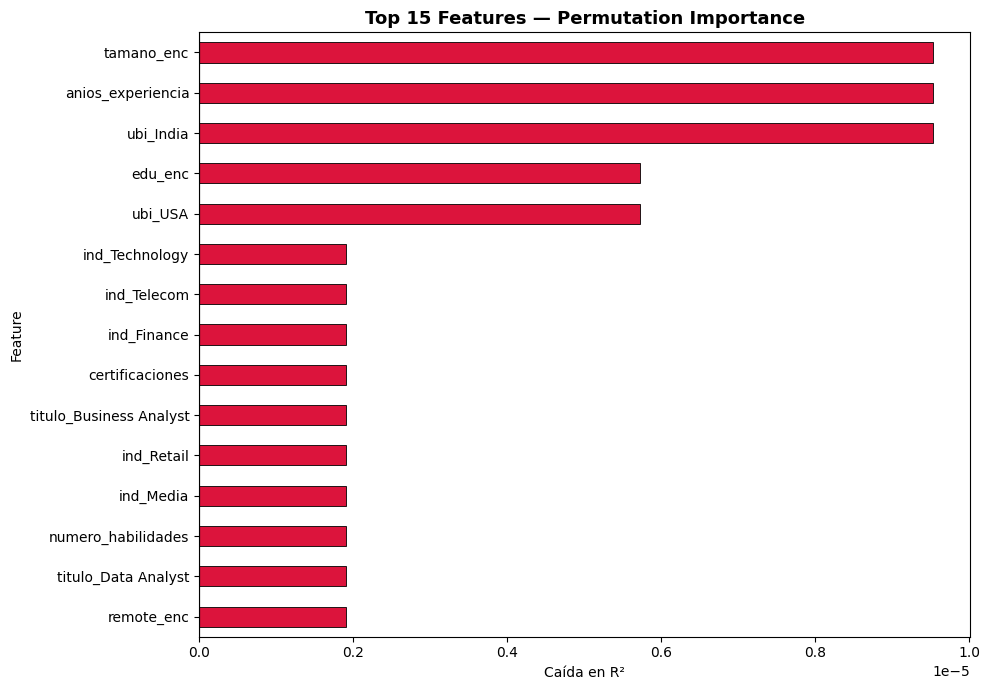

    ✓ Gráfico guardado: permutation_importance_salarios.png


In [17]:
# =============================================================================
# 11. IMPORTANCIA DE FEATURES (Permutation Importance)
# =============================================================================
print("\n[11] Calculando Permutation Importance...")
print("    (Nota: con 250k muestras esto puede tardar unos minutos)\n")

importancias = {}
r2_base = r2_score(y_test, model.predict(X_test_sc, verbose=0).flatten())

for i, col in enumerate(X.columns):
    X_permutado = X_test_sc.copy()
    np.random.seed(42)
    X_permutado[:, i] = np.random.permutation(X_permutado[:, i])
    y_perm_pred  = model.predict(X_permutado, verbose=0).flatten()
    r2_permutado = r2_score(y_test, y_perm_pred)
    importancias[col] = r2_base - r2_permutado

imp_series = pd.Series(importancias).sort_values(ascending=False)

print("\n📊 Caída en R² al permutar cada variable (top 15):")
print(imp_series.head(15).round(4))

# Solo mostramos top 15 para legibilidad
imp_top = imp_series.head(15).sort_values()

plt.figure(figsize=(10, 7))
colores = ["crimson" if v > 0 else "steelblue" for v in imp_top]
imp_top.plot(kind="barh", color=colores, edgecolor="k", linewidth=0.6)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 Features — Permutation Importance", fontsize=13, fontweight="bold")
plt.ylabel("Feature")
plt.xlabel("Caída en R²")
plt.tight_layout()
plt.savefig("permutation_importance_salarios.png", dpi=150, bbox_inches="tight")
plt.show()
print("    ✓ Gráfico guardado: permutation_importance_salarios.png")


In [18]:
# =============================================================================
# 12. PREDICCIÓN CON NUEVOS PROFESIONALES
# =============================================================================
print("\n[12] Predicción con nuevos perfiles profesionales...")

# Obtenemos las columnas one-hot del dataset para construir nuevas obs correctamente
titulo_cols   = [c for c in feature_cols if c.startswith("titulo_")]
industria_cols = [c for c in feature_cols if c.startswith("ind_")]
ubicacion_cols = [c for c in feature_cols if c.startswith("ubi_")]

def crear_obs(titulo, industria, ubicacion, anios_exp, nivel_edu,
              num_habilidades, tamano_empresa, trabajo_remoto, certificaciones):
    """Construye una fila de features lista para predecir."""
    row = {col: 0 for col in feature_cols}
    row["anios_experiencia"]  = anios_exp
    row["edu_enc"]            = {"High School":0,"Diploma":1,"Bachelor":2,"Master":3,"PhD":4}[nivel_edu]
    row["numero_habilidades"] = num_habilidades
    row["tamano_enc"]         = {"Startup":0,"Small":1,"Medium":2,"Large":3,"Enterprise":4}[tamano_empresa]
    row["remote_enc"]         = {"No":0,"Hybrid":1,"Yes":2}[trabajo_remoto]
    row["certificaciones"]    = certificaciones
    # One-hot: activar la columna correspondiente si existe (drop_first omite la primera)
    col_t = f"titulo_{titulo.replace(' ', '_')}"
    col_i = f"ind_{industria}"
    col_u = f"ubi_{ubicacion}"
    if col_t in row: row[col_t] = 1
    if col_i in row: row[col_i] = 1
    if col_u in row: row[col_u] = 1
    return row

perfiles = [
    crear_obs("AI Engineer",           "Technology",    "USA",       15, "PhD",         19, "Enterprise", "Yes",    5),
    crear_obs("Data Analyst",          "Retail",        "India",      2, "Bachelor",     5, "Small",      "No",     0),
    crear_obs("Software Engineer",     "Finance",       "Germany",   10, "Master",      12, "Large",      "Hybrid", 3),
    crear_obs("Machine Learning Engineer","Consulting", "Canada",     8, "Master",      17, "Medium",     "Yes",    4),
    crear_obs("Frontend Developer",    "Media",         "India",      1, "High School",  3, "Startup",    "No",     0),
]

etiquetas = [
    "AI Engineer Senior  (PhD, 15 años, USA)",
    "Data Analyst Junior (Bachelor, 2 años, India)",
    "Software Engineer   (Master, 10 años, Alemania)",
    "ML Engineer         (Master, 8 años, Canadá)",
    "Frontend Junior     (High School, 1 año, India)",
]

X_nuevos = pd.DataFrame(perfiles)[feature_cols]
X_nuevos_sc = scaler_X.transform(X_nuevos)
preds_sc    = model.predict(X_nuevos_sc, verbose=0)
preds_real  = scaler_y.inverse_transform(preds_sc).ravel()

print("\n    Resultados de predicción:")
print(f"    {'Perfil':<45} {'Salario estimado':>18}")
print("    " + "-" * 65)
for etq, pred in zip(etiquetas, preds_real):
    print(f"    {etq:<45} ${pred:>14,.0f}")



[12] Predicción con nuevos perfiles profesionales...

    Resultados de predicción:
    Perfil                                          Salario estimado
    -----------------------------------------------------------------
    AI Engineer Senior  (PhD, 15 años, USA)       $       310,575
    Data Analyst Junior (Bachelor, 2 años, India) $        89,402
    Software Engineer   (Master, 10 años, Alemania) $       203,934
    ML Engineer         (Master, 8 años, Canadá)  $       202,294
    Frontend Junior     (High School, 1 año, India) $        75,654


### Predicción personalizada
Modifica los parámetros de `crear_obs(...)` para predecir el salario de cualquier perfil.

In [19]:
# Opciones válidas:
# titulo_profesional : AI Engineer, Data Analyst, Frontend Developer, Business Analyst,
#                      Product Manager, Backend Developer, Machine Learning Engineer,
#                      DevOps Engineer, Software Engineer, Cybersecurity Analyst, Cloud Engineer
# nivel_educativo    : High School, Diploma, Bachelor, Master, PhD
# industria          : Healthcare, Telecom, Media, Retail, Manufacturing,
#                      Education, Finance, Technology, Consulting, Government
# tamaño_empresa     : Startup, Small, Medium, Large, Enterprise
# ubicación          : India, Australia, Singapore, Canada, Sweden,
#                      USA, Netherlands, Remote, Germany, UK
# trabajo_remoto     : No, Hybrid, Yes

mi_perfil = crear_obs(
    titulo         = "Data Scientist",
    industria      = "Finance",
    ubicacion      = "UK",
    anios_exp      = 5,
    nivel_edu      = "Master",
    num_habilidades= 10,
    tamano_empresa = "Large",
    trabajo_remoto = "Hybrid",
    certificaciones= 3
)

X_custom    = pd.DataFrame([mi_perfil])[feature_cols]
X_custom_sc = scaler_X.transform(X_custom)
pred_custom = scaler_y.inverse_transform(model.predict(X_custom_sc, verbose=0)).ravel()

print(f"\n    Salario anual estimado: ${pred_custom[0]:,.0f} USD")



    Salario anual estimado: $195,197 USD


In [20]:
# =============================================================================
# RESUMEN FINAL
# =============================================================================
print("\n" + "=" * 65)
print("   RESUMEN FINAL")
print("=" * 65)
print(f"   Dataset       : Salarios Tech ({len(df):,} muestras, {X.shape[1]} features)")
print(f"   Épocas reales : {epocas_reales}")
print(f"   RMSE test     : ${rmse:,.2f} USD")
print(f"   MAE test      : ${mae:,.2f} USD  → error promedio de predicción")
print(f"   R² test       : {r2:.4f}  → {r2*100:.1f}% varianza explicada")
print(f"\n   Archivos generados:")
print(f"   ├── correlacion_salarios.png")
print(f"   ├── exploratorio_salarios.png")
print(f"   ├── categoricas_salarios.png")
print(f"   ├── resultados_salarios.png")
print(f"   ├── importancia_variables_salarios.png")
print(f"   ├── permutation_importance_salarios.png")
print(f"   └── mejor_modelo_salarios.keras")
print("=" * 65)
print("   PROCESO COMPLETADO EXITOSAMENTE ✓")
print("=" * 65)



   RESUMEN FINAL
   Dataset       : Salarios Tech (250,000 muestras, 35 features)
   Épocas reales : 60
   RMSE test     : $5,996.52 USD
   MAE test      : $4,780.94 USD  → error promedio de predicción
   R² test       : 0.9741  → 97.4% varianza explicada

   Archivos generados:
   ├── correlacion_salarios.png
   ├── exploratorio_salarios.png
   ├── categoricas_salarios.png
   ├── resultados_salarios.png
   ├── importancia_variables_salarios.png
   ├── permutation_importance_salarios.png
   └── mejor_modelo_salarios.keras
   PROCESO COMPLETADO EXITOSAMENTE ✓
